# **Machine Learning Assignment :- 9**


**   **
**Name: Ghrushnesh Sudhakar Patil**

**Class: CSAI-D**     

**Batch : 3**

**Roll No: 66**

**PRN: 12411658**



---



**Q. Write a program to do following:**

**This dataset gives the data of Income and money spent by the customers visiting a shopping mall. The data set contains Customer ID, Gender, Age, Annual Income, Spending Score. Therefore, as a mall owner you need to find the group of people who are the profitable customers for the mall owner. Apply at least two clustering algorithms (based on Spending Score) to find the group of customers.**


**DATASET LINK :- [ https://www.kaggle.com/shwetabh123/mall-customers]( https://www.kaggle.com/shwetabh123/mall-customers/)**

**A).	Apply Data pre-processing**

**B).	Perform data-preparation (Train-Test Split)**

**C).	Apply Machine Learning Algorithm**

**D).	Evaluate Model.**




In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

In [ ]:
data = pd.read_csv("/content/Mall_Customers.csv")

data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# A). Applying Data Pre-Processing

In [ ]:
encoder = LabelEncoder()
data['Genre'] = encoder.fit_transform(data['Genre'])

In [ ]:
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# B). Perform data-preparation (Train-Test Split)

In [ ]:
X_train, X_test = train_test_split(X_scaled, test_size=0.6, random_state=42)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

Training data size: (80, 2)
Testing data size: (120, 2)


#C).	Applying Machine Learning Algorithm

###K-Means Clustering

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)

kmeans_labels = kmeans.fit_predict(X_train)

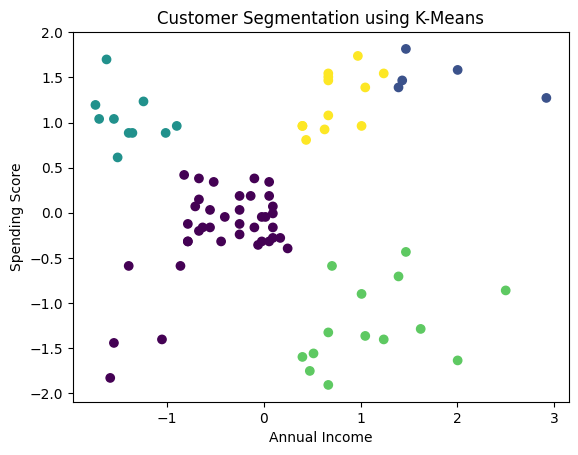

In [ ]:
plt.scatter(X_train[:,0], X_train[:,1], c=kmeans_labels)
plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()

###Heirarchial Clustering

In [ ]:
hc = AgglomerativeClustering(n_clusters=5)

hc_labels = hc.fit_predict(X_train)

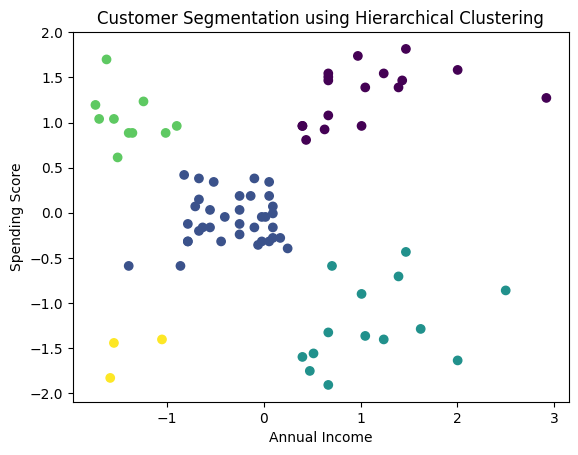

In [ ]:
plt.scatter(X_train[:,0], X_train[:,1], c=hc_labels)
plt.title("Customer Segmentation using Hierarchical Clustering")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()

# D).	Evaluate Model

In [ ]:
kmeans_score = silhouette_score(X_train, kmeans_labels)
hc_score = silhouette_score(X_train, hc_labels)

print("K-Means Silhouette Score:", kmeans_score)
print("Hierarchical Clustering Silhouette Score:", hc_score)

K-Means Silhouette Score: 0.5020542119325657
Hierarchical Clustering Silhouette Score: 0.5708471227415485
